<a href="https://colab.research.google.com/github/thechiragbatra/customer-churn-mlops/blob/main/2_uplift.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

!pip install causalml xgboost mlflow -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 80.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.9/76.9 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 106.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 75.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 70.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.

In [3]:
# ── CELL 2: Load + Prepare Data ───────────────────────
from google.colab import files
uploaded = files.upload()  # upload customer_churn_dataset.csv again

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn 2.csv')

# Same cleaning as before
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df.drop('customerID', axis=1, inplace=True)

# Encode categoricals
from sklearn.preprocessing import LabelEncoder
cat_cols = df.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("✅ Shape:", df.shape)
print("✅ Data ready for uplift modeling!")

Saving WA_Fn-UseC_-Telco-Customer-Churn 2.csv to WA_Fn-UseC_-Telco-Customer-Churn 2 (1).csv
✅ Shape: (7032, 20)
✅ Data ready for uplift modeling!


In [4]:
# ── CELL 3: Create Treatment Column ───────────────────
np.random.seed(42)

# Simulate A/B test — 30% of customers received a retention offer
df['treatment'] = np.random.binomial(1, 0.3, size=len(df))

print("Treatment distribution:")
print(df['treatment'].value_counts())
print(f"\nTreatment rate: {df['treatment'].mean():.1%}")

# Features, treatment, outcome
X = df.drop(['Churn', 'treatment'], axis=1)
treatment = df['treatment']
y = df['Churn']

print("\n✅ Treatment column created!")

Treatment distribution:
treatment
0    4962
1    2070
Name: count, dtype: int64

Treatment rate: 29.4%

✅ Treatment column created!


In [5]:
# ── CELL 4: Train Uplift Model ─────────────────────────
from causalml.inference.meta import BaseTClassifier
from xgboost import XGBClassifier

# T-Learner: trains separate models for treatment vs control
learner = BaseTClassifier(
    learner=XGBClassifier(n_estimators=100, max_depth=4,
                          random_state=42, eval_metric='logloss')
)

# Fit uplift model
learner.fit(X=X.values, treatment=treatment.values, y=y.values)

# Get Individual Treatment Effects (ITE)
ite = learner.predict(X=X.values)
df['ite_score'] = ite.flatten()

print("ITE Score Summary:")
print(df['ite_score'].describe())
print("\n✅ Uplift model trained!")

ITE Score Summary:
count    7032.000000
mean       -0.008097
std         0.186638
min        -0.834469
25%        -0.080167
50%        -0.003754
75%         0.051351
max         0.792108
Name: ite_score, dtype: float64

✅ Uplift model trained!


📊 Customer Segments:
segment
Sleeping Dog    3838
Sure Thing      1325
Lost Cause      1050
Persuadable      819
Name: count, dtype: int64

Total customers: 7032

💰 Revenue Impact Analysis:
   Total churners:              1869
   Persuadable customers:       819
   Cost targeting everyone:     $93,450
   Cost targeting persuadables: $40,950
   💵 Budget saved:             $52,500 (56.2%)


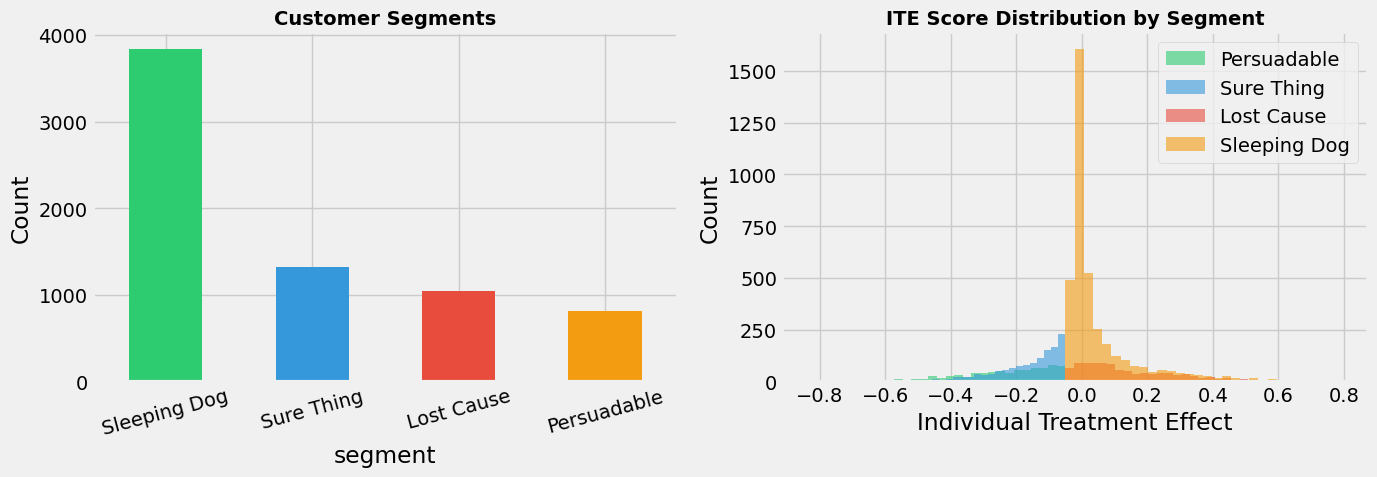


✅ Segmentation complete!


In [6]:
# ── CELL 5: Customer Segmentation ─────────────────────
# Segment customers into 4 buckets
def segment_customer(row):
    if row['Churn'] == 1 and row['ite_score'] < -0.05:
        return 'Persuadable'      # High churn risk + responds to offer
    elif row['Churn'] == 0 and row['ite_score'] < -0.05:
        return 'Sure Thing'       # Low churn risk anyway
    elif row['Churn'] == 1 and row['ite_score'] >= -0.05:
        return 'Lost Cause'       # High churn risk, won't respond
    else:
        return 'Sleeping Dog'     # Low risk but offer might backfire

df['segment'] = df.apply(segment_customer, axis=1)

print("📊 Customer Segments:")
print(df['segment'].value_counts())
print(f"\nTotal customers: {len(df)}")

# Revenue Impact Calculation
discount_value = 50  # assume $50 retention offer per customer
total_customers = len(df)
persuadables = len(df[df['segment'] == 'Persuadable'])
all_churners = len(df[df['Churn'] == 1])

cost_target_all    = all_churners * discount_value
cost_target_persuadables = persuadables * discount_value
budget_saved = cost_target_all - cost_target_persuadables
pct_saved = (budget_saved / cost_target_all) * 100

print(f"\n💰 Revenue Impact Analysis:")
print(f"   Total churners:              {all_churners}")
print(f"   Persuadable customers:       {persuadables}")
print(f"   Cost targeting everyone:     ${cost_target_all:,}")
print(f"   Cost targeting persuadables: ${cost_target_persuadables:,}")
print(f"   💵 Budget saved:             ${budget_saved:,} ({pct_saved:.1f}%)")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Segment distribution
colors = ['#2ecc71','#3498db','#e74c3c','#f39c12']
df['segment'].value_counts().plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Customer Segments', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)

# ITE distribution by segment
for segment, color in zip(['Persuadable','Sure Thing','Lost Cause','Sleeping Dog'], colors):
    subset = df[df['segment'] == segment]['ite_score']
    axes[1].hist(subset, bins=30, alpha=0.6, label=segment, color=color)
axes[1].set_title('ITE Score Distribution by Segment', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Individual Treatment Effect')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('uplift_segments.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Segmentation complete!")